### Pre-processing Pipeline

####   Prepare and preprocess the dataset. Build a per-identity training/validation/test split. Apply consistent image resizing, normalization, and  augmentation strategy (random crop, horizontal flip, color jitter).

This notebook documents and runs the preprocessing pipeline. All logic lives in
[`src/preprocessing.py`](src/preprocessing.py), so the training notebooks use exactly the same code. The same
split can be regenerated from the command line with `python src/preprocessing.py`.

| Step | What | Where |
|---|---|---|
| 1 | Index images and identity labels | `scan_images` |
| 2 | Integrity check (readable, RGB, size) and exact-duplicate detection | `validate_images` |
| 3 | Per-identity stratified 60 / 20 / 20 train / val / test split, seed 42 | `make_splits` -> `data/splits.csv` |
| 4 | Resize 224 px + ImageNet normalization; train-only augmentation | `get_transforms` |
| 5 | In-memory `Dataset` + `DataLoader`s | `get_dataloaders` |

#### 0. Environment setup (local Jupyter or Google Colab)
On **Colab**: `Runtime -> Change runtime type -> T4 GPU` (Or other GPU depending on availability. CPU also works, but slower), then run this cell.
By default it mounts Google Drive and uses (or clones) the repo at `MyDrive/IE7615-Group3-Project1`, so results,
logs and checkpoints persist after the session ends. Cloning the private repo needs a GitHub personal access token
saved as a Colab secret named `GITHUB_TOKEN` (key icon in the left sidebar). Locally, the cell just finds the repo root.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")  # Colab secret holding a GitHub access token
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "preprocessing.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print("Project root:", PROJECT_ROOT)
print("PyTorch", torch.__version__, "| device:", "cuda - " + torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
Project root: /content/drive/MyDrive/IE7615-Group3-Project1
PyTorch 2.11.0+cu128 | device: cuda - Tesla T4


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from src import preprocessing as pp

FIG_DIR = PROJECT_ROOT / "results" / "milestone1" / "preprocessing"
FIG_DIR.mkdir(parents=True, exist_ok=True)

#### 1. Celebrity subset

We use **4 distinct CelebA identities**. CelebA publishes identities as anonymous integer IDs
(`identity_CelebA.txt`), so we refer to each class by its CelebA ID (`id_<ID>`). The images are CelebA's
*aligned & cropped* faces (178 x 218 px), stored as `data/celeba/<identity_id>/<celeba_filename>.jpg`.

Selection rationale:
* **Enough images per identity.** Each chosen identity has 24-25 images, near the upper end of
  what CelebA provides per identity, which gives 14-15 training images per class after the split.
* **Balanced classes.** The class counts differ by at most one image, so accuracy is not skewed by class imbalance
  and no re-weighting is needed.
* **Visual diversity with a hard pair.** The subset mixes one male and three female identities with different hair
  colour and styling, pose, lighting and background. Two of the female identities (`id_2970`, `id_4422`) have
  similar age and hair colour. That pair is a deliberately hard case that tests whether a model learns identity
  rather than coarse attributes like gender or hair colour.
* **Realistic variation.** Images span different events, years, expressions and lighting.

In [3]:
df = pp.scan_images(pp.IMAGE_DIR)
class_names = pp.class_names_from(df)
print(f"{len(df)} images, {df['identity'].nunique()} identities -> classes {class_names}")
df.groupby("identity").size().rename("n_images").to_frame().T

99 images, 4 identities -> classes ['id_2336', 'id_2970', 'id_4422', 'id_7007']


identity,2336,2970,4422,7007
n_images,25,25,25,24


#### 2. Data validation
Check every file opens, is RGB, has the expected size, and is not an exact duplicate (because a duplicate landing in both train and test would leak test data).

In [4]:
df = pp.validate_images(df, pp.IMAGE_DIR)
print("Unreadable files:", int((~df["ok"]).sum()))
print("Colour modes:", df["mode"].value_counts().to_dict())
print("Image sizes (w x h):", df.groupby(["width", "height"]).size().to_dict())
dups = df[df.duplicated("md5", keep=False)]
print("Exact duplicates:", len(dups))
if len(dups):
    display(dups.sort_values("md5"))
df = df[df["ok"]].drop_duplicates("md5").reset_index(drop=True)

Unreadable files: 0
Colour modes: {'RGB': 99}
Image sizes (w x h): {(178, 218): 99}
Exact duplicates: 0


**Sample images** (5 per identity):

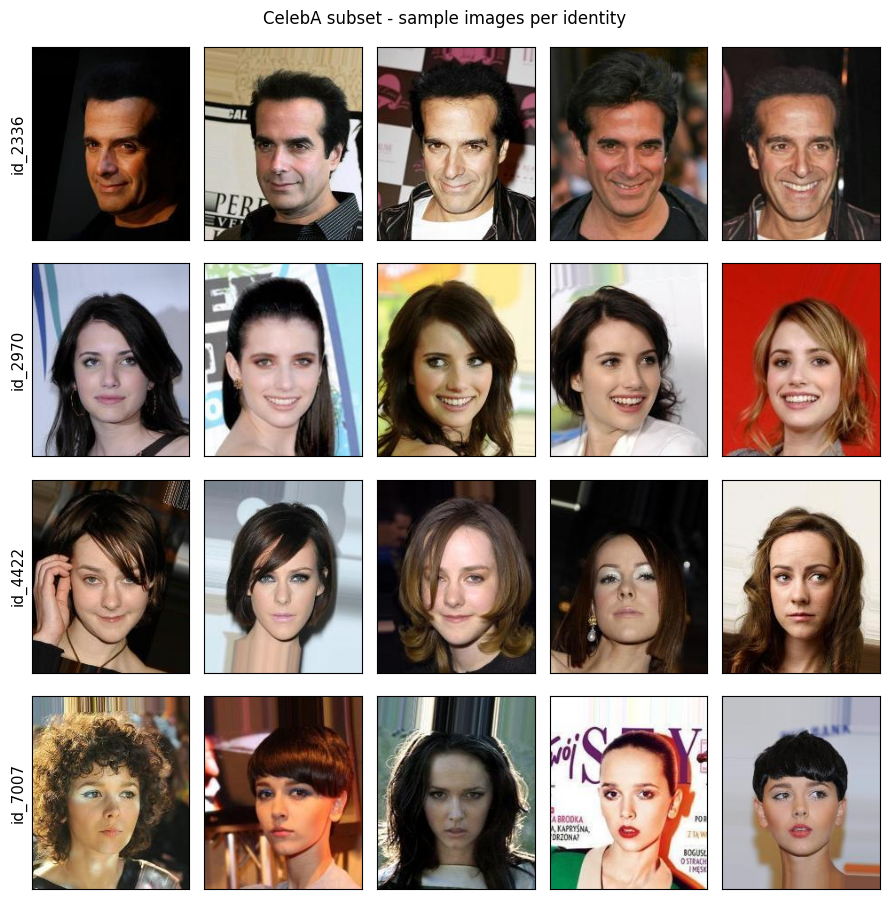

In [5]:
n_show = 5
fig, axes = plt.subplots(len(class_names), n_show, figsize=(n_show * 1.8, len(class_names) * 2.3))
for r, (identity, g) in enumerate(df.groupby("identity")):
    for c, rel in enumerate(g["path"].sample(n_show, random_state=0)):
        ax = axes[r, c]
        ax.imshow(Image.open(pp.IMAGE_DIR / rel))
        ax.set_xticks([]); ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(f"id_{identity}", fontsize=11)
fig.suptitle("CelebA subset - sample images per identity")
fig.tight_layout()
fig.savefig(FIG_DIR / "sample_images.png", dpi=150, bbox_inches="tight")

#### 3. Per-identity train / validation / test split
Each identity is shuffled independently (seed 42) and cut 60 / 20 / 20, so every identity appears in every split
with the same proportions. We chose 60/20/20 over 70/15/15 because, with 25 images per identity, 70/15/15 would leave only
3-4 test images per class; 5 per class makes per-class accuracy and the confusion matrix more meaningful. The
split is saved to `data/splits.csv` to be reused by every training notebook.

In [6]:
splits = pp.make_splits(df, val_fraction=pp.VAL_FRACTION, test_fraction=pp.TEST_FRACTION, seed=pp.SEED)
pp.save_splits(splits, pp.SPLITS_CSV)
print("Saved", pp.SPLITS_CSV.relative_to(PROJECT_ROOT))
display(pp.split_summary(splits))

# Leakage checks: no file and no identical image content shared between splits
by_split = {s: g for s, g in splits.groupby("split")}
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    assert not set(by_split[a]["path"]) & set(by_split[b]["path"]), f"path overlap {a}/{b}"
    assert not set(by_split[a]["md5"]) & set(by_split[b]["md5"]), f"duplicate image {a}/{b}"
print("No overlap between splits.")

Saved data/splits.csv


split,train,val,test,total
identity,,,,
2336,15,5,5,25
2970,15,5,5,25
4422,15,5,5,25
7007,14,5,5,24
total,59,20,20,99


No overlap between splits.


#### 4. Resizing, normalisation and augmentation

**Resizing (all splits, all models):** resize the short side to 224 px (178x218 -> 224x274), then crop to
**224 x 224**. The same input size for every architecture makes results comparable, and it matches the ImageNet
pretraining resolution.

**Normalisation:** ImageNet channel mean/std. This is required for the pretrained backbones, and we use it for the
custom CNN as well for consistency.

**Augmentation (training split only):**

| Transform | Setting | Why |
|---|---|---|
| `RandomResizedCrop` | 70-100% area, aspect 0.85-1.15 | framing / scale / small translation changes |
| `RandomHorizontalFlip` | p = 0.5 | faces are roughly left-right symmetric; identity is unchanged |
| `RandomRotation` | +/-10 deg | head tilt |
| `ColorJitter` | brightness/contrast/saturation 0.3, hue 0.05 | lighting and camera differences between events |

Validation and test images use a deterministic centre crop, so evaluation is repeatable.

In [7]:
mean, std = pp.compute_channel_stats(splits, pp.IMAGE_DIR)
pd.DataFrame({"subset (train) mean": mean, "ImageNet mean": pp.IMAGENET_MEAN,
              "subset (train) std": std, "ImageNet std": pp.IMAGENET_STD},
             index=["R", "G", "B"]).round(3)

,subset (train) mean,ImageNet mean,subset (train) std,ImageNet std
R,0.507,0.485,0.313,0.229
G,0.441,0.456,0.295,0.224
B,0.405,0.406,0.300,0.225


In [8]:
print("Train transform:\n", pp.get_transforms(train=True))
print("\nEval transform:\n", pp.get_transforms(train=False))

Train transform:
 Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), ratio=(0.85, 1.15), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

Eval transform:
 Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


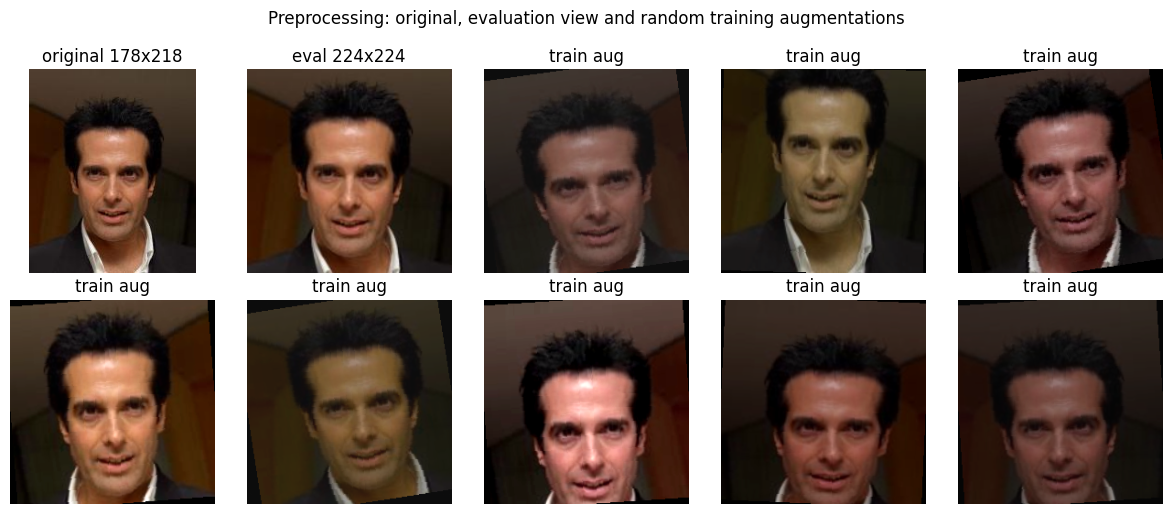

In [9]:
import torch
torch.manual_seed(0)
rel = splits[splits["split"] == "train"]["path"].iloc[0]
img = Image.open(pp.IMAGE_DIR / rel).convert("RGB")
train_tf, eval_tf = pp.get_transforms(True), pp.get_transforms(False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5.2))
axes = axes.ravel()
axes[0].imshow(img); axes[0].set_title("original 178x218")
axes[1].imshow(pp.denormalize(eval_tf(img)).permute(1, 2, 0)); axes[1].set_title("eval 224x224")
for ax in axes[2:]:
    ax.imshow(pp.denormalize(train_tf(img)).permute(1, 2, 0)); ax.set_title("train aug")
for ax in axes:
    ax.axis("off")
fig.suptitle("Preprocessing: original, evaluation view and random training augmentations")
fig.tight_layout()
fig.savefig(FIG_DIR / "augmentation_examples.png", dpi=150, bbox_inches="tight")

#### 5. DataLoaders sanity check

In [10]:
loaders, class_names = pp.get_dataloaders(splits, batch_size=16)
for name, dl in loaders.items():
    labels = pd.Series(dl.dataset.labels).map(dict(enumerate(class_names))).value_counts().sort_index()
    print(f"{name:5s}: {len(dl.dataset):3d} images, {len(dl)} batches | {labels.to_dict()}")
x, y = next(iter(loaders["train"]))
print("Batch tensor:", tuple(x.shape), x.dtype, f"| value range [{x.min():.2f}, {x.max():.2f}]")

train:  59 images, 4 batches | {'id_2336': 15, 'id_2970': 15, 'id_4422': 15, 'id_7007': 14}
val  :  20 images, 2 batches | {'id_2336': 5, 'id_2970': 5, 'id_4422': 5, 'id_7007': 5}
test :  20 images, 2 batches | {'id_2336': 5, 'id_2970': 5, 'id_4422': 5, 'id_7007': 5}
Batch tensor: (16, 3, 224, 224) torch.float32 | value range [-2.12, 2.64]


**Summary.** Four balanced CelebA identities (99 images) were validated (no corrupt files, all 178x218 RGB),
split per identity into 59 / 20 / 20 train / val / test images (these are number of images, not percentage), and wrapped in DataLoaders that apply identical
224 px resizing and ImageNet normalisation to every model, with augmentation on the training split only.